In [ ]:
!pip install apted lxml
!pip install -U transformers==4.41.2 accelerate peft bitsandbytes datasets
!pip install -U transformers accelerate peft bitsandbytes
!pip install -U bitsandbytes>=0.46.1
!pip install -U accelerate
!pip install tokenizers==0.19.1
!pip install huggingface-hub==0.35.0
!pip install -U transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 93.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 35.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 50.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 54.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 45.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 120.7 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.7.1
    Uninstalling huggingface_hub-1.7.1:
      Successfully uninstalled huggingface_hub-1.7.1
  Attempting uninsta

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import torch
from transformers import AutoProcessor, AutoModelForImageTextToText, BitsAndBytesConfig

model_id = "Qwen/Qwen2.5-VL-3B-Instruct"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)

model = AutoModelForImageTextToText.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True
)
# 🔥 ADD THESE TWO LINES
model.gradient_checkpointing_enable()
model.config.use_cache = False
processor = AutoProcessor.from_pretrained(
    model_id,
    trust_remote_code=True
)

print("Qwen2.5-VL loaded successfully.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Qwen2.5-VL loaded successfully.


In [ ]:
import torch
print(torch.cuda.memory_allocated()/1024**3, "GB allocated")
print(torch.cuda.memory_reserved()/1024**3, "GB reserved")

2.2678914070129395 GB allocated
6.68359375 GB reserved


In [ ]:
from datasets import load_dataset
import os

dataset_path = "/content/drive/MyDrive/DataSet/2kSubset"

# Check structure first
print("Files inside dataset folder:")
print(os.listdir(dataset_path))

print("Number of images:")
print(len(os.listdir(os.path.join(dataset_path, "images_2k"))))

# Load JSON
dataset = load_dataset(
    "json",
    data_files=os.path.join(dataset_path, "train_2k_chat.jsonl")
)

dataset = dataset["train"]

print("\nSample entry:")
print(dataset[0])

Files inside dataset folder:
['train_2k_chat.jsonl', 'images_2k']
Number of images:
2000


Generating train split: 0 examples [00:00, ? examples/s]


Sample entry:
{'messages': [{'role': 'user', 'content': '<image>\nExtract the full table structure in HTML format.'}, {'role': 'assistant', 'content': '<thead><tr><td></td><td colspan="6"></td></tr><tr><td></td><td></td><td></td><td></td><td></td><td></td><td></td></tr></thead><tbody><tr><td></td><td></td><td></td><td></td><td></td><td></td><td></td></tr><tr><td></td><td></td><td></td><td></td><td></td><td></td><td></td></tr><tr><td></td><td></td><td></td><td></td><td></td><td></td><td></td></tr><tr><td></td><td></td><td></td><td></td><td></td><td></td><td></td></tr><tr><td></td><td></td><td></td><td></td><td></td><td></td><td></td></tr><tr><td></td><td></td><td></td><td></td><td></td><td></td><td></td></tr><tr><td></td><td></td><td></td><td></td><td></td><td></td><td></td></tr><tr><td></td><td></td><td></td><td></td><td></td><td></td><td></td></tr><tr><td></td><td></td><td></td><td></td><td></td><td></td><td></td></tr><tr><td></td><td></td><td></td><td></td><td></td><td></td><td></td

In [ ]:
# ===== FIX DATA FORMAT FOR QWEN2.5-VL (CORRECT LABEL MASKING) =====
# ================================================================
# DATA PREPARATION FOR MULTIMODAL INSTRUCTION FINE-TUNING
# ---------------------------------------------------------------
# 1. Load image corresponding to JSON entry
# 2. Create instruction-style chat format (image + question → HTML)
# 3. Convert into Qwen2.5-VL chat template format
# 4. Tokenize image + text together
# 5. Mask labels so model learns ONLY assistant HTML output
# ================================================================
from datasets import load_dataset
from PIL import Image
import os
import torch

dataset_path = "/content/drive/MyDrive/DataSet/2kSubset"

raw_dataset = load_dataset(
    "json",
    data_files=os.path.join(dataset_path, "train_2k_chat.jsonl")
)["train"]

def preprocess(example):
    image_path = os.path.join(dataset_path, "images_2k", example["image"])
    image = Image.open(image_path).convert("RGB")

    assistant_text = example["messages"][1]["content"].strip().replace("\n", "")

    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image"},
                {"type": "text", "text": "Extract the full table structure in HTML format."}
            ],
        },
        {
            "role": "assistant",
            "content": assistant_text
        }
    ]

    text = processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=False
    )

    inputs = processor(
        text=text,
        images=image,
        return_tensors="pt"
    )

    inputs = {k: v.squeeze(0) for k, v in inputs.items()}

    # ===============================
    # ✅ Correct label masking
    # ===============================

    full_input_ids = inputs["input_ids"]
    assistant_input = processor.tokenizer(
        assistant_text,
        add_special_tokens=False,
        return_tensors="pt"
    )["input_ids"].squeeze(0)

    labels = torch.full_like(full_input_ids, -100)

    # Find where assistant text starts in full input
    for i in range(len(full_input_ids) - len(assistant_input)):
        if torch.equal(
            full_input_ids[i:i+len(assistant_input)],
            assistant_input
        ):
            labels[i:i+len(assistant_input)] = assistant_input
            break

    inputs["labels"] = labels

    return inputs


dataset = raw_dataset.map(
    preprocess,
    remove_columns=raw_dataset.column_names
)

print("✅ Dataset fixed with correct assistant-only training.")

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

✅ Dataset fixed with correct assistant-only training.


In [ ]:
#Attach QLora
from peft import LoraConfig, get_peft_model

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

model = get_peft_model(model, lora_config)

model.print_trainable_parameters()

NameError: name 'model' is not defined

In [ ]:
# ==============================
# TRAINER (IMPROVED VERSION)
# ==============================

from transformers import TrainingArguments, Trainer
import os

output_dir = "/content/drive/MyDrive/DataSet/Qwen_VL_3B_2K_Finetune"
os.makedirs(output_dir, exist_ok=True)

training_args = TrainingArguments(
    output_dir=output_dir,

    # -------- Training core --------
    per_device_train_batch_size=1,
    gradient_accumulation_steps=8,
    num_train_epochs=3,
    learning_rate=5e-5,          # 🔥 added
    warmup_ratio=0.1,            # 🔥 added
    lr_scheduler_type="cosine",  # 🔥 smoother convergence

    # -------- Memory stability --------
    fp16=True,
    gradient_checkpointing=True,
    max_grad_norm=1.0,           # 🔥 prevents exploding gradients

    # -------- Logging --------
    logging_steps=25,

    # -------- Checkpointing --------
    save_strategy="steps",
    save_steps=100,
    save_total_limit=3,

    # -------- Disable external logging --------
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset,
)

trainer.train()

# Save final LoRA adapter
final_model_path = os.path.join(output_dir, "FINAL_MODEL_2K")
trainer.save_model(final_model_path)
processor.save_pretrained(final_model_path)

print("✅ Training complete and safely saved.")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`...


Step,Training Loss
25,0.284444
50,0.187765
75,0.114319
100,0.042036
125,0.038961
150,0.036877
175,0.034792
200,0.025670
225,0.029230
250,0.032078


✅ Training complete and safely saved.


**Training of 5k Dataset**

In [ ]:
import os

dataset_path = "/content/drive/MyDrive/DataSet/5kSubset"

print(os.listdir(dataset_path))
print(len(os.listdir(dataset_path + "/images_5k")))

['train_5k_chat.jsonl', 'images_5k']
5000


In [ ]:
# ===== FIX DATA FORMAT FOR QWEN2.5-VL (CORRECT LABEL MASKING) =====
# ================================================================
# DATA PREPARATION FOR MULTIMODAL INSTRUCTION FINE-TUNING
# ---------------------------------------------------------------
# 1. Load image corresponding to JSON entry
# 2. Create instruction-style chat format (image + question → HTML)
# 3. Convert into Qwen2.5-VL chat template format
# 4. Tokenize image + text together
# 5. Mask labels so model learns ONLY assistant HTML output
# ================================================================
from datasets import load_dataset
from PIL import Image
import os
import torch

dataset_path = "/content/drive/MyDrive/DataSet/5kSubset"

raw_dataset = load_dataset(
    "json",
    data_files=os.path.join(dataset_path, "train_5k_chat.jsonl")
)["train"]

def preprocess(example):
    image_path = os.path.join(dataset_path, "images_5k", example["image"])
    image = Image.open(image_path).convert("RGB")

    assistant_text = example["messages"][1]["content"].strip().replace("\n", "")

    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image"},
                {"type": "text", "text": "Extract the full table structure in HTML format."}
            ],
        },
        {
            "role": "assistant",
            "content": assistant_text
        }
    ]

    text = processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=False
    )

    inputs = processor(
        text=text,
        images=image,
        return_tensors="pt"
    )

    inputs = {k: v.squeeze(0) for k, v in inputs.items()}

    # ===============================
    # ✅ Correct label masking
    # ===============================

    full_input_ids = inputs["input_ids"]
    assistant_input = processor.tokenizer(
        assistant_text,
        add_special_tokens=False,
        return_tensors="pt"
    )["input_ids"].squeeze(0)

    labels = torch.full_like(full_input_ids, -100)

    # Find where assistant text starts in full input
    for i in range(len(full_input_ids) - len(assistant_input)):
        if torch.equal(
            full_input_ids[i:i+len(assistant_input)],
            assistant_input
        ):
            labels[i:i+len(assistant_input)] = assistant_input
            break

    inputs["labels"] = labels

    return inputs


dataset = raw_dataset.map(
    preprocess,
    remove_columns=raw_dataset.column_names
)

print("✅ Dataset fixed with correct assistant-only training.")

Generating train split: 0 examples [00:00, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

✅ Dataset fixed with correct assistant-only training.


In [ ]:
# ==============================
# TRAINER (IMPROVED VERSION)
# ==============================

from transformers import TrainingArguments, Trainer
import os

output_dir = "/content/drive/MyDrive/DataSet/Qwen_VL_3B_5K_Finetune"
os.makedirs(output_dir, exist_ok=True)

training_args = TrainingArguments(
    output_dir=output_dir,

    # -------- Training core --------
    per_device_train_batch_size=1,
    gradient_accumulation_steps=8,
    num_train_epochs=3,
    learning_rate=5e-5,          # 🔥 added
    warmup_ratio=0.1,            # 🔥 added
    lr_scheduler_type="cosine",  # 🔥 smoother convergence

    # -------- Memory stability --------
    fp16=True,
    gradient_checkpointing=True,
    max_grad_norm=1.0,           # 🔥 prevents exploding gradients

    # -------- Logging --------
    logging_steps=25,

    # -------- Checkpointing --------
    save_strategy="steps",
    save_steps=100,
    save_total_limit=3,

    # -------- Disable external logging --------
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset,
)

#trainer.train()
trainer.train(resume_from_checkpoint="/content/drive/MyDrive/DataSet/Qwen_VL_3B_5K_Finetune/checkpoint-1100")

# Save final LoRA adapter
final_model_path = os.path.join(output_dir, "FINAL_MODEL_5K")
trainer.save_model(final_model_path)
processor.save_pretrained(final_model_path)

print("✅ Training complete and safely saved.")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Step,Training Loss
1125,0.022726
1150,0.021873
1175,0.023199
1200,0.023517
1225,0.019599
1250,0.021461
1275,0.020355
1300,0.021305
1325,0.020440
1350,0.026368


✅ Training complete and safely saved.


**10k Training**

In [ ]:
# ================================================================
# DATA PREPARATION FOR QWEN2.5-VL (OPTIMIZED + HTML NORMALIZATION)
# ================================================================

from datasets import load_dataset
from PIL import Image
import os
import torch
import re

dataset_path = "/content/drive/MyDrive/DataSet/10kSubset"

# ---------------- LOAD DATASET ----------------
raw_dataset = load_dataset(
    "json",
    data_files=os.path.join(dataset_path, "train_10k_chat.jsonl")
)["train"]

print("Total samples:", len(raw_dataset))


# ---------------- HTML NORMALIZATION ----------------
def clean_html(html):

    html = html.strip()

    # remove tabs and newlines
    html = html.replace("\n", "").replace("\t", "")

    # normalize spacing
    html = re.sub(r"\s+", " ", html)

    # normalize tag formatting
    html = html.replace("<td >", "<td>")
    html = html.replace("<tr >", "<tr>")
    html = html.replace("<thead >", "<thead>")
    html = html.replace("<tbody >", "<tbody>")

    # remove trailing spaces
    html = html.strip()

    return html


# ---------------- PREPROCESS FUNCTION ----------------
def preprocess(example):

    image_path = os.path.join(dataset_path, "images_10k", example["image"])

    # safe image loading
    with Image.open(image_path) as img:
        image = img.convert("RGB")

    # clean assistant HTML
    assistant_text = example["messages"][1]["content"]
    assistant_text = clean_html(assistant_text)

    # build multimodal chat
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image"},
                {"type": "text", "text": "Extract the full table structure in HTML format."}
            ],
        },
        {
            "role": "assistant",
            "content": assistant_text
        }
    ]

    # convert to Qwen chat format
    text = processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=False
    )

    # tokenize multimodal input
    inputs = processor(
        text=text,
        images=image,
        return_tensors="pt"
    )

    inputs = {k: v.squeeze(0) for k, v in inputs.items()}

    # ===============================
    # LABEL MASKING (assistant only)
    # ===============================

    full_input_ids = inputs["input_ids"]

    assistant_tokens = processor.tokenizer(
        assistant_text,
        add_special_tokens=False,
        return_tensors="pt"
    )["input_ids"].squeeze(0)

    labels = torch.full_like(full_input_ids, -100)

    # locate assistant token span
    for i in range(len(full_input_ids) - len(assistant_tokens)):
        if torch.equal(full_input_ids[i:i+len(assistant_tokens)], assistant_tokens):
            labels[i:i+len(assistant_tokens)] = assistant_tokens
            break

    inputs["labels"] = labels

    return inputs


# ---------------- APPLY PREPROCESSING ----------------
dataset = raw_dataset.map(
    preprocess,
    remove_columns=raw_dataset.column_names,
    num_proc=2
)

print("✅ Dataset preprocessing complete.")
print("Final dataset size:", len(dataset))

Total samples: 10000


Map (num_proc=2):   0%|          | 0/10000 [00:00<?, ? examples/s]

✅ Dataset preprocessing complete.
Final dataset size: 10000


In [ ]:
# ==============================
# TRAINER (OPTIMIZED FOR 10K TRAINING)
# ==============================

from transformers import TrainingArguments, Trainer
import os

output_dir = "/content/drive/MyDrive/DataSet/Qwen_VL_3B_10K_Finetune"
os.makedirs(output_dir, exist_ok=True)

training_args = TrainingArguments(
    output_dir=output_dir,

    # -------- Training core --------
    per_device_train_batch_size=1,
    gradient_accumulation_steps=8,

    num_train_epochs=3,

    learning_rate=3e-5,          # 🔥 lower LR for stable convergence
    warmup_ratio=0.05,           # 🔥 smaller warmup
    lr_scheduler_type="cosine",

    # -------- Stability --------
    fp16=True,
    gradient_checkpointing=True,
    max_grad_norm=1.0,

    # -------- Logging --------
    logging_steps=50,

    # -------- Checkpoints --------
    save_strategy="steps",
    save_steps=200,              # 🔥 fewer checkpoints (saves time)
    save_total_limit=3,

    # -------- Performance --------
    dataloader_num_workers=2,
    remove_unused_columns=False,

    # -------- Disable external logging --------
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset,
)

# Start training
#trainer.train()
trainer.train(resume_from_checkpoint="/content/drive/MyDrive/DataSet/Qwen_VL_3B_10K_Finetune/checkpoint-2200")

# Save final LoRA adapter
final_model_path = os.path.join(output_dir, "FINAL_MODEL_10K")
trainer.save_model(final_model_path)
processor.save_pretrained(final_model_path)

print("✅ 10K Training complete and model saved.")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Step,Training Loss
2250,0.020079
2300,0.019656
2350,0.020728
2400,0.023053
2450,0.021774
2500,0.020351
2550,0.018520
2600,0.019723
2650,0.019579
2700,0.020475


✅ 10K Training complete and model saved.


In [ ]:
!pip install apted lxml
!pip install -U transformers==4.41.2 accelerate peft bitsandbytes datasets
!pip install -U transformers accelerate peft bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 4.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 114.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 39.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 45.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 53.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 50.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 116.1 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.7.1
    Uninstalling huggingface_hub-1.7.1:
      Successfully uninstalled huggingface_hub-1.7.1
  Attempting uninst

In [ ]:
#Load FintuneModel
import torch
from transformers import AutoProcessor, AutoModelForImageTextToText, BitsAndBytesConfig
from peft import PeftModel

base_model_id = "Qwen/Qwen2.5-VL-3B-Instruct"
adapter_path = "/content/drive/MyDrive/DataSet/Qwen_VL_3B_10K_Finetune/FINAL_MODEL_10K"

# 4-bit config
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)

# Load base model first
model = AutoModelForImageTextToText.from_pretrained(
    base_model_id,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True
)

# Load LoRA adapter
model = PeftModel.from_pretrained(model, adapter_path)

processor = AutoProcessor.from_pretrained(
    base_model_id,
    trust_remote_code=True
)

processor.tokenizer.padding_side="left"
processor.tokenizer.pad_token=processor.tokenizer.eos_token
model.eval()

print("✅ Base model + LoRA adapter loaded successfully.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✅ Base model + LoRA adapter loaded successfully.


In [ ]:
# ==========================================================
# BATCHED RESUMABLE VALIDATION (GPU OPTIMIZED)
# ==========================================================

import os
import json
import torch
from PIL import Image
from apted import APTED, Config
from lxml import etree
from io import StringIO

# ---------------- GPU SPEED SETTINGS ----------------
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

# ---------------- SETTINGS ----------------
MAX_IMAGES = 9115
MAX_TOKENS = 768
BATCH_SIZE = 6

val_folder = "/content/drive/MyDrive/DataSet/val"
json_path = "/content/drive/MyDrive/DataSet/PubTabNet_2.0.0.jsonl"

progress_file = "/content/drive/MyDrive/DataSet/full_validation_progress_10k.json"
log_file = "/content/drive/MyDrive/DataSet/full_validation_logs_10k.json"

# ---------------- LOAD GT ----------------
print("Loading ground truth...")
gt_dict = {}

with open(json_path, "r", encoding="utf-8") as f:
    for line in f:
        entry = json.loads(line)
        gt_dict[entry["filename"]] = "".join(entry["html"]["structure"]["tokens"])

print("GT loaded.\n")

# ---------------- TEDS ----------------
class TableTreeConfig(Config):
    def children(self, node):
        return list(node)

    def rename(self, node1, node2):
        return 0 if node1.tag == node2.tag else 1

def html_to_tree(html_string):
    parser = etree.HTMLParser(remove_blank_text=True)
    tree = etree.parse(StringIO(html_string), parser)
    return tree.getroot()

def compute_teds(gt_html, pred_html):
    gt_tree = html_to_tree(gt_html)
    pred_tree = html_to_tree(pred_html)
    apted = APTED(gt_tree, pred_tree, TableTreeConfig())
    edit_distance = apted.compute_edit_distance()
    max_nodes = max(len(list(gt_tree.iter())), len(list(pred_tree.iter())))
    return 1 - (edit_distance / max_nodes)

# ---------------- LOAD PROGRESS ----------------
if os.path.exists(progress_file):
    with open(progress_file, "r") as f:
        saved = json.load(f)
    processed_images = set(saved["processed"])
    teds_scores = saved["scores"]
    print(f"Resuming from {len(processed_images)} images\n")
else:
    processed_images = set()
    teds_scores = []

if os.path.exists(log_file):
    with open(log_file, "r") as f:
        detailed_logs = json.load(f)
else:
    detailed_logs = []

# ---------------- IMAGE LIST ----------------
image_list = sorted(os.listdir(val_folder))[:MAX_IMAGES]
image_list = [img for img in image_list if img in gt_dict and img not in processed_images]

print(f"Remaining images: {len(image_list)}\n")

# ---------------- BATCH LOOP ----------------
for i in range(0, len(image_list), BATCH_SIZE):

    batch_images = image_list[i:i+BATCH_SIZE]
    images = []
    texts = []

    for image_name in batch_images:
        image_path = os.path.join(val_folder, image_name)
        image = Image.open(image_path).convert("RGB")
        images.append(image)

        messages = [{
            "role": "user",
            "content": [
                {"type": "image"},
                {"type": "text", "text": "Extract the full table structure in HTML format."}
            ]
        }]

        text = processor.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True
        )

        texts.append(text)

    inputs = processor(
        text=texts,
        images=images,
        return_tensors="pt",
        padding=True
    ).to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=MAX_TOKENS,
            do_sample=False,
            num_beams=1
        )

    decoded = processor.batch_decode(outputs, skip_special_tokens=True)

    # -------- PROCESS EACH OUTPUT --------
    for image_name, output_text in zip(batch_images, decoded):

        assistant_output = output_text.split("assistant")[-1].strip()
        gt_html = gt_dict[image_name]

        try:
            score = compute_teds(gt_html, assistant_output)
            teds_scores.append(score)
            processed_images.add(image_name)

            detailed_logs.append({
                "image": image_name,
                "teds": score
            })

        except:
            continue

    # -------- SAVE PROGRESS --------
    # -------- SAVE PROGRESS (EVERY BATCH) --------
    with open(progress_file, "w") as f:
        json.dump({
            "processed": list(processed_images),
            "scores": teds_scores
        }, f)

    with open(log_file, "w") as f:
        json.dump(detailed_logs, f)

    current_avg = sum(teds_scores) / len(teds_scores)
    print(f"Processed {len(processed_images)}/{MAX_IMAGES} | Avg TEDS: {current_avg:.4f}")

# ---------------- FINAL SAVE ----------------
with open(progress_file, "w") as f:
    json.dump({
        "processed": list(processed_images),
        "scores": teds_scores
    }, f)

with open(log_file, "w") as f:
    json.dump(detailed_logs, f)

print("\n" + "="*60)
if len(teds_scores) > 0:
    final_avg = sum(teds_scores) / len(teds_scores)
    print(f"🔥 FINAL AVG TEDS: {final_avg:.4f}")
else:
    print("No valid scores computed.")
print("="*60)

Loading ground truth...
GT loaded.

Resuming from 8604 images

Remaining images: 510



The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
/usr/local/lib/python3.12/dist-packages/apted/node_indexer.py:331: FutureWarning: Truth-testing of elements was a source of confusion and will always return True in future versions. Use specific 'len(elem)' or 'elem is not None' test instead.
  return bool(self.node)


Processed 8610/9115 | Avg TEDS: 0.8089
Processed 8616/9115 | Avg TEDS: 0.8088
Processed 8622/9115 | Avg TEDS: 0.8087
Processed 8628/9115 | Avg TEDS: 0.8087
Processed 8634/9115 | Avg TEDS: 0.8087
Processed 8640/9115 | Avg TEDS: 0.8087
Processed 8646/9115 | Avg TEDS: 0.8088
Processed 8652/9115 | Avg TEDS: 0.8088
Processed 8658/9115 | Avg TEDS: 0.8087
Processed 8664/9115 | Avg TEDS: 0.8087
Processed 8670/9115 | Avg TEDS: 0.8088
Processed 8676/9115 | Avg TEDS: 0.8087
Processed 8682/9115 | Avg TEDS: 0.8087
Processed 8688/9115 | Avg TEDS: 0.8087
Processed 8694/9115 | Avg TEDS: 0.8088
Processed 8700/9115 | Avg TEDS: 0.8088
Processed 8706/9115 | Avg TEDS: 0.8089
Processed 8712/9115 | Avg TEDS: 0.8088
Processed 8718/9115 | Avg TEDS: 0.8088
Processed 8724/9115 | Avg TEDS: 0.8089
Processed 8730/9115 | Avg TEDS: 0.8088
Processed 8736/9115 | Avg TEDS: 0.8089
Processed 8742/9115 | Avg TEDS: 0.8088
Processed 8748/9115 | Avg TEDS: 0.8087
Processed 8754/9115 | Avg TEDS: 0.8087
Processed 8760/9115 | Avg

**FinTabNet**

In [ ]:
# ==========================================================
# FIN TAB NET BATCHED RESUMABLE VALIDATION (FINAL)
# ==========================================================

import os
import json
import torch
from PIL import Image
from apted import APTED, Config
from lxml import etree
from io import StringIO

# ---------------- GPU SPEED SETTINGS ----------------
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

# ---------------- SETTINGS ----------------
MAX_IMAGES = 830
MAX_TOKENS = 768
BATCH_SIZE = 6

# -------- PATHS --------
val_folder = "/content/drive/MyDrive/DataSet/FinTabNet/fintab_1000/fintab_1000"
json_path = "/content/drive/MyDrive/DataSet/FinTabNet/FinTabNet_1.0.0_table_test.jsonl"

progress_file = "/content/drive/MyDrive/DataSet/FinTabNet/fintab_validation_progress.json"
log_file = "/content/drive/MyDrive/DataSet/FinTabNet/fintab_validation_logs.json"

# ==========================================================
# BUILD HTML FROM FINTABNET JSON
# ==========================================================

def fintabnet_to_html(entry):
    structure = entry["html"]["structure"]["tokens"]
    cells = entry["html"]["cells"]

    html = ""
    cell_index = 0

    for token in structure:
        html += token
        if token == "<td>":
            html += "".join(cells[cell_index]["tokens"])
            cell_index += 1

    return html


# ==========================================================
# LOAD GROUND TRUTH
# ==========================================================

print("Loading FinTabNet ground truth...")

gt_dict = {}

with open(json_path, "r", encoding="utf-8") as f:
    for line in f:
        entry = json.loads(line)
        pdf_name = entry["filename"]
        gt_dict[pdf_name] = fintabnet_to_html(entry)

print(f"Ground truth loaded: {len(gt_dict)} samples\n")


# ==========================================================
# TEDS IMPLEMENTATION
# ==========================================================

class TableTreeConfig(Config):
    def children(self, node):
        return list(node)

    def rename(self, node1, node2):
        return 0 if node1.tag == node2.tag else 1


def html_to_tree(html_string):
    parser = etree.HTMLParser(remove_blank_text=True)
    tree = etree.parse(StringIO(html_string), parser)
    return tree.getroot()


def compute_teds(gt_html, pred_html):
    gt_tree = html_to_tree(gt_html)
    pred_tree = html_to_tree(pred_html)

    apted = APTED(gt_tree, pred_tree, TableTreeConfig())
    edit_distance = apted.compute_edit_distance()

    max_nodes = max(len(list(gt_tree.iter())),
                    len(list(pred_tree.iter())))

    return 1 - (edit_distance / max_nodes)


# ==========================================================
# LOAD PROGRESS
# ==========================================================

if os.path.exists(progress_file):
    with open(progress_file, "r") as f:
        saved = json.load(f)

    processed_images = set(saved["processed"])
    teds_scores = saved["scores"]

    print(f"Resuming from {len(processed_images)} images\n")

else:
    processed_images = set()
    teds_scores = []

if os.path.exists(log_file):
    with open(log_file, "r") as f:
        detailed_logs = json.load(f)
else:
    detailed_logs = []


# ==========================================================
# IMAGE LIST
# ==========================================================

image_list = sorted(os.listdir(val_folder))[:MAX_IMAGES]

image_list = [
    img for img in image_list
    if img not in processed_images
]

print(f"Remaining images: {len(image_list)}\n")


# ==========================================================
# BATCH LOOP
# ==========================================================

for i in range(0, len(image_list), BATCH_SIZE):

    batch_images = image_list[i:i+BATCH_SIZE]

    images = []
    texts = []
    pdf_names = []

    for image_name in batch_images:

        image_path = os.path.join(val_folder, image_name)
        image = Image.open(image_path).convert("RGB")
        images.append(image)

        # ✅ CORRECT MAPPING (UPDATED)
        base_name = image_name.replace("_table.png", "")
        #pdf_name = base_name.replace("_", "/") + ".pdf"
        parts = image_name.replace("_table.png", "").split("_")
        # first two → folder
        pdf_name = f"{parts[0]}/{parts[1]}/" + "_".join(parts[2:]) + ".pdf"

        pdf_names.append(pdf_name)
        #print("IMAGE:", image_name)
        #print("PDF:", pdf_name)
        #print("GT FOUND:", pdf_name in gt_dict)

        # prompt
        messages = [{
            "role": "user",
            "content": [
                {"type": "image"},
                {"type": "text", "text": "Extract the full table structure in HTML format."}
            ]
        }]

        text = processor.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True
        )

        texts.append(text)

    inputs = processor(
        text=texts,
        images=images,
        return_tensors="pt",
        padding=True
    ).to(model.device)

    # ---------------- MODEL GENERATION ----------------

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=MAX_TOKENS,
            do_sample=False,
            num_beams=1
        )

    decoded = processor.batch_decode(outputs, skip_special_tokens=True)

    # ==========================================================
    # PROCESS OUTPUT
    # ==========================================================

    for image_name, pdf_name, output_text in zip(batch_images, pdf_names, decoded):

        assistant_output = output_text.split("assistant")[-1].strip()
        gt_html = gt_dict.get(pdf_name, None)

        if gt_html is None:
            print(f"⚠️ GT not found for: {pdf_name}")
            continue

        try:
            score = compute_teds(gt_html, assistant_output)

            teds_scores.append(score)
            processed_images.add(image_name)

            detailed_logs.append({
                "image": image_name,
                "teds": score
            })

        except Exception as e:
            print("Error in TEDS:", e)
            continue


    # ==========================================================
    # SAVE PROGRESS
    # ==========================================================

    with open(progress_file, "w") as f:
        json.dump({
            "processed": list(processed_images),
            "scores": teds_scores
        }, f)

    with open(log_file, "w") as f:
        json.dump(detailed_logs, f)

    # ✅ SAFE AVERAGE
    if len(teds_scores) > 0:
        current_avg = sum(teds_scores) / len(teds_scores)
    else:
        current_avg = 0

    print(f"Processed {len(processed_images)}/{MAX_IMAGES} | Avg TEDS: {current_avg:.4f}")


# ==========================================================
# FINAL RESULTS
# ==========================================================

print("\n" + "="*60)

if len(teds_scores) > 0:
    final_avg = sum(teds_scores) / len(teds_scores)
    print(f"🔥 FINAL AVG TEDS: {final_avg:.4f}")
else:
    print("❌ No valid scores computed.")

print("="*60)

Loading FinTabNet ground truth...
Ground truth loaded: 5903 samples

Resuming from 432 images

Remaining images: 398

Processed 438/830 | Avg TEDS: 0.7096
Processed 444/830 | Avg TEDS: 0.7087
Processed 450/830 | Avg TEDS: 0.7070
Processed 456/830 | Avg TEDS: 0.7076
Processed 462/830 | Avg TEDS: 0.7083
Processed 468/830 | Avg TEDS: 0.7074
Processed 474/830 | Avg TEDS: 0.7091
Processed 480/830 | Avg TEDS: 0.7096
Processed 486/830 | Avg TEDS: 0.7102
Processed 492/830 | Avg TEDS: 0.7074
Processed 498/830 | Avg TEDS: 0.7077
Processed 504/830 | Avg TEDS: 0.7083


KeyboardInterrupt: 

**BaseModel**

In [ ]:
import torch
from transformers import AutoProcessor, AutoModelForImageTextToText, BitsAndBytesConfig

base_model_id = "Qwen/Qwen2.5-VL-3B-Instruct"

# 4-bit config (same as before for fair comparison)
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)

# 🔥 Load ONLY base model (NO LoRA here)
model = AutoModelForImageTextToText.from_pretrained(
    base_model_id,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True
)

# Load processor
processor = AutoProcessor.from_pretrained(
    base_model_id,
    trust_remote_code=True
)

# tokenizer settings (same as before)
processor.tokenizer.padding_side = "left"
processor.tokenizer.pad_token = processor.tokenizer.eos_token

model.eval()

print("✅ Base model loaded successfully (no fine-tuning)")

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

✅ Base model loaded successfully (no fine-tuning)


In [ ]:
# ==========================================================
# BASE MODEL EVALUATION (1000 IMAGES - RESUMABLE)
# ==========================================================

import os
import json
import torch
from PIL import Image
from apted import APTED, Config
from lxml import etree
from io import StringIO

# ---------------- GPU SPEED SETTINGS ----------------
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

# ---------------- SETTINGS ----------------
MAX_IMAGES = 1000   # ✅ changed
MAX_TOKENS = 768
BATCH_SIZE = 6

val_folder = "/content/drive/MyDrive/DataSet/val"
json_path = "/content/drive/MyDrive/DataSet/PubTabNet_2.0.0.jsonl"

# ✅ changed file names
progress_file = "/content/drive/MyDrive/DataSet/base_model_progress.json"
log_file = "/content/drive/MyDrive/DataSet/base_model_logs.json"

# ---------------- LOAD GT ----------------
print("Loading ground truth...")
gt_dict = {}

with open(json_path, "r", encoding="utf-8") as f:
    for line in f:
        entry = json.loads(line)
        gt_dict[entry["filename"]] = "".join(entry["html"]["structure"]["tokens"])

print("GT loaded.\n")

# ---------------- TEDS ----------------
class TableTreeConfig(Config):
    def children(self, node):
        return list(node)

    def rename(self, node1, node2):
        return 0 if node1.tag == node2.tag else 1

def html_to_tree(html_string):
    parser = etree.HTMLParser(remove_blank_text=True)
    tree = etree.parse(StringIO(html_string), parser)
    return tree.getroot()

def compute_teds(gt_html, pred_html):
    gt_tree = html_to_tree(gt_html)
    pred_tree = html_to_tree(pred_html)
    apted = APTED(gt_tree, pred_tree, TableTreeConfig())
    edit_distance = apted.compute_edit_distance()
    max_nodes = max(len(list(gt_tree.iter())), len(list(pred_tree.iter())))
    return 1 - (edit_distance / max_nodes)

# ---------------- LOAD PROGRESS ----------------
if os.path.exists(progress_file):
    with open(progress_file, "r") as f:
        saved = json.load(f)
    processed_images = set(saved["processed"])
    teds_scores = saved["scores"]
    print(f"Resuming from {len(processed_images)} images\n")
else:
    processed_images = set()
    teds_scores = []

if os.path.exists(log_file):
    with open(log_file, "r") as f:
        detailed_logs = json.load(f)
else:
    detailed_logs = []

# ---------------- IMAGE LIST ----------------
image_list = sorted(os.listdir(val_folder))[:MAX_IMAGES]
image_list = [img for img in image_list if img in gt_dict and img not in processed_images]

print(f"Remaining images: {len(image_list)}\n")

# ---------------- BATCH LOOP ----------------
for i in range(0, len(image_list), BATCH_SIZE):

    batch_images = image_list[i:i+BATCH_SIZE]
    images = []
    texts = []

    for image_name in batch_images:
        image_path = os.path.join(val_folder, image_name)
        image = Image.open(image_path).convert("RGB")
        images.append(image)

        messages = [{
            "role": "user",
            "content": [
                {"type": "image"},
                {"type": "text", "text": "Extract the full table structure in HTML format."}
            ]
        }]

        text = processor.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True
        )

        texts.append(text)

    inputs = processor(
        text=texts,
        images=images,
        return_tensors="pt",
        padding=True
    ).to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=MAX_TOKENS,
            do_sample=False,
            num_beams=1
        )

    decoded = processor.batch_decode(outputs, skip_special_tokens=True)

    # -------- PROCESS EACH OUTPUT --------
    for image_name, output_text in zip(batch_images, decoded):

        assistant_output = output_text.split("assistant")[-1].strip()
        gt_html = gt_dict[image_name]

        try:
            score = compute_teds(gt_html, assistant_output)
            teds_scores.append(score)
            processed_images.add(image_name)

            detailed_logs.append({
                "image": image_name,
                "teds": score
            })

        except:
            continue

    # -------- SAVE PROGRESS (EVERY BATCH) --------
    with open(progress_file, "w") as f:
        json.dump({
            "processed": list(processed_images),
            "scores": teds_scores
        }, f)

    with open(log_file, "w") as f:
        json.dump(detailed_logs, f)

    current_avg = sum(teds_scores) / len(teds_scores)
    print(f"Processed {len(processed_images)}/{MAX_IMAGES} | Avg TEDS: {current_avg:.4f}")

# ---------------- FINAL SAVE ----------------
with open(progress_file, "w") as f:
    json.dump({
        "processed": list(processed_images),
        "scores": teds_scores
    }, f)

with open(log_file, "w") as f:
    json.dump(detailed_logs, f)

print("\n" + "="*60)
if len(teds_scores) > 0:
    final_avg = sum(teds_scores) / len(teds_scores)
    print(f"🔥 FINAL BASE MODEL TEDS: {final_avg:.4f}")
else:
    print("No valid scores computed.")
print("="*60)

Loading ground truth...
GT loaded.

Remaining images: 1000



The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
/usr/local/lib/python3.12/dist-packages/apted/node_indexer.py:331: FutureWarning: Truth-testing of elements was a source of confusion and will always return True in future versions. Use specific 'len(elem)' or 'elem is not None' test instead.
  return bool(self.node)


Processed 6/1000 | Avg TEDS: 0.7401
Processed 12/1000 | Avg TEDS: 0.7130
Processed 18/1000 | Avg TEDS: 0.7060
Processed 24/1000 | Avg TEDS: 0.6625
Processed 30/1000 | Avg TEDS: 0.6634
Processed 36/1000 | Avg TEDS: 0.6772
Processed 42/1000 | Avg TEDS: 0.6708
Processed 48/1000 | Avg TEDS: 0.6830
Processed 54/1000 | Avg TEDS: 0.6860
Processed 60/1000 | Avg TEDS: 0.6760
Processed 66/1000 | Avg TEDS: 0.6670
Processed 72/1000 | Avg TEDS: 0.6712
Processed 78/1000 | Avg TEDS: 0.6748
Processed 84/1000 | Avg TEDS: 0.6739
Processed 90/1000 | Avg TEDS: 0.6729
Processed 96/1000 | Avg TEDS: 0.6779
Processed 102/1000 | Avg TEDS: 0.6682
Processed 108/1000 | Avg TEDS: 0.6786
Processed 114/1000 | Avg TEDS: 0.6812
Processed 120/1000 | Avg TEDS: 0.6817
Processed 126/1000 | Avg TEDS: 0.6726
Processed 132/1000 | Avg TEDS: 0.6788
Processed 138/1000 | Avg TEDS: 0.6795
Processed 144/1000 | Avg TEDS: 0.6762
Processed 150/1000 | Avg TEDS: 0.6734
Processed 156/1000 | Avg TEDS: 0.6730
Processed 162/1000 | Avg TEDS

In [ ]:
import json
import random

# Load logs
with open("/content/drive/MyDrive/DataSet/full_validation_logs_10k.json") as f:
    data = json.load(f)

# Split based on TEDS
easy = [x for x in data if x["teds"] > 0.85]
medium = [x for x in data if 0.6 <= x["teds"] <= 0.85]
hard = [x for x in data if x["teds"] < 0.6]

# Select 3 from each
selected = random.sample(easy, 3) + random.sample(medium, 3) + random.sample(hard, 3)

# Extract image names
selected_images = [x["image"] for x in selected]

# ✅ Save automatically
with open("/content/drive/MyDrive/DataSet/qualitative_images.json", "w") as f:
    json.dump(selected_images, f)

# Print
print("Selected Images:")
for img in selected_images:
    print(img)

Selected Images:
PMC5299665_004_00.png
PMC5732455_006_00.png
PMC3446508_005_01.png
PMC4986276_009_00.png
PMC3132165_002_00.png
PMC3580989_004_00.png
PMC5591999_002_01.png
PMC6073449_005_00.png
PMC3798567_003_00.png


In [ ]:
import json

# ---------------- PATH ----------------
json_path = "/content/drive/MyDrive/DataSet/PubTabNet_2.0.0.jsonl"

# ---------------- LOAD SELECTED IMAGES ----------------
with open("/content/drive/MyDrive/DataSet/qualitative_images.json") as f:
    selected_images = json.load(f)

# ---------------- EXTRACT GT ----------------
gt_dict = {}

with open(json_path, "r", encoding="utf-8") as f:
    for line in f:
        entry = json.loads(line)

        filename = entry["filename"]

        if filename in selected_images:

            # ✅ ONLY STRUCTURE (NO CONTENT)
            structure_tokens = entry["html"]["structure"]["tokens"]
            html = "".join(structure_tokens)

            gt_dict[filename] = html

# ---------------- SAVE ----------------
with open("/content/drive/MyDrive/DataSet/qualitative_gt.json", "w") as f:
    json.dump(gt_dict, f)

print("✅ GT (structure-only) extracted successfully")

✅ GT (structure-only) extracted successfully


In [ ]:
import json
from PIL import Image
import os

# Load selected images
with open("/content/drive/MyDrive/DataSet/qualitative_images.json") as f:
    selected_images = json.load(f)

val_folder = "/content/drive/MyDrive/DataSet/val"

base_outputs = {}

for image_name in selected_images:
    image_path = os.path.join(val_folder, image_name)
    image = Image.open(image_path).convert("RGB")

    messages = [{
        "role": "user",
        "content": [
            {"type": "image"},
            {"type": "text", "text": "Extract ONLY the table structure in HTML. Do NOT include any cell content. Return empty <td></td> cells."}
        ]
    }]

    text = processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = processor(
        text=[text],
        images=[image],
        return_tensors="pt"
    ).to(model.device)

    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=768,
            do_sample=False
        )

    decoded = processor.batch_decode(output, skip_special_tokens=True)[0]

    pred = decoded.split("assistant")[-1].strip()
    base_outputs[image_name] = pred

# Save
with open("/content/drive/MyDrive/DataSet/base_outputs.json", "w") as f:
    json.dump(base_outputs, f)

print("✅ Base model predictions saved")

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


✅ Base model predictions saved


In [ ]:
import json
from PIL import Image
import os
import torch

# Load selected images
with open("/content/drive/MyDrive/DataSet/qualitative_images.json") as f:
    selected_images = json.load(f)

val_folder = "/content/drive/MyDrive/DataSet/val"

finetuned_outputs = {}

for image_name in selected_images:
    image_path = os.path.join(val_folder, image_name)
    image = Image.open(image_path).convert("RGB")

    messages = [{
        "role": "user",
        "content": [
            {"type": "image"},
            {"type": "text", "text": "Extract ONLY the table structure in HTML. Do NOT include any cell content. Return empty <td></td> cells."}
        ]
    }]

    text = processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = processor(
        text=[text],
        images=[image],
        return_tensors="pt"
    ).to(model.device)

    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=768,
            do_sample=False
        )

    decoded = processor.batch_decode(output, skip_special_tokens=True)[0]

    pred = decoded.split("assistant")[-1].strip()
    finetuned_outputs[image_name] = pred

# ✅ Save AFTER loop
with open("/content/drive/MyDrive/DataSet/finetuned_outputs.json", "w") as f:
    json.dump(finetuned_outputs, f)

print("✅ Finetuned model predictions saved")

✅ Finetuned model predictions saved


In [ ]:
import json
import os
from PIL import Image, ImageDraw
from bs4 import BeautifulSoup

# ---------------- LOAD DATA ----------------
with open("/content/drive/MyDrive/DataSet/qualitative_images.json") as f:
    selected_images = json.load(f)

with open("/content/drive/MyDrive/DataSet/qualitative_gt.json") as f:
    gt_data = json.load(f)

with open("/content/drive/MyDrive/DataSet/finetuned_outputs.json") as f:
    finetuned_outputs = json.load(f)

val_folder = "/content/drive/MyDrive/DataSet/val"
output_folder = "/content/drive/MyDrive/DataSet/qualitative_results_final"
os.makedirs(output_folder, exist_ok=True)


# ---------------- DRAW TRUE STRUCTURE ----------------
def draw_true_structure(html, border_color, cell_w=80, cell_h=60):

    soup = BeautifulSoup(html, "html.parser")
    rows = soup.find_all("tr")

    if not rows:
        return Image.new("RGB", (300, 300), "white")

    # calculate dynamic width (based on longest row)
    max_cols = max(len(r.find_all(["td", "th"])) for r in rows)

    img = Image.new("RGB", (max_cols * cell_w, len(rows) * cell_h), "white")
    draw = ImageDraw.Draw(img)

    for i, row in enumerate(rows):
        cols = row.find_all(["td", "th"])

        for j, col in enumerate(cols):  # 🔥 ONLY actual cells

            x1 = j * cell_w
            y1 = i * cell_h
            x2 = x1 + cell_w
            y2 = y1 + cell_h

            draw.rectangle([x1, y1, x2, y2], outline=border_color, width=3)

    return img


# ---------------- LABEL ----------------
def add_label(img, text):
    labeled = Image.new("RGB", (img.width, img.height + 40), "white")
    draw = ImageDraw.Draw(labeled)
    draw.text((10, 10), text, fill=(0, 0, 0))
    labeled.paste(img, (0, 40))
    return labeled


# ---------------- MAIN ----------------
for img_name in selected_images:

    # Input
    input_img = Image.open(os.path.join(val_folder, img_name)).convert("RGB").resize((400, 400))
    #input_img = Image.open(os.path.join(val_folder, img_name)).convert("RGB")
    #input_img.thumbnail((400, 400))   # instead of resize
    input_img = add_label(input_img, "Input")

    # Ground Truth
    gt_img = draw_true_structure(gt_data[img_name], (0, 0, 0)).resize((400, 400))
    gt_img = add_label(gt_img, "Ground Truth")

    # Finetuned (TRUE prediction)
    ft_img = draw_true_structure(finetuned_outputs[img_name], (0, 0, 255)).resize((400, 400))
    ft_img = add_label(ft_img, "Fine-tuned Model")

    # Combine
    combined = Image.new("RGB", (1200, 400), "white")

    combined.paste(input_img, (0, 0))
    combined.paste(gt_img, (400, 0))
    combined.paste(ft_img, (800, 0))

    combined.save(os.path.join(output_folder, img_name))


print("🔥 TRUE STRUCTURE (missing cells visible) generated!")

🔥 TRUE STRUCTURE (missing cells visible) generated!


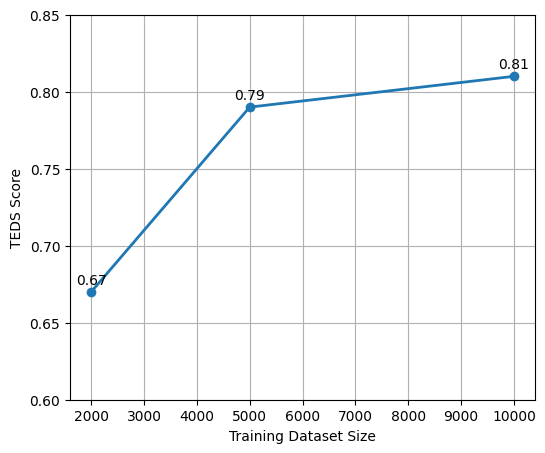

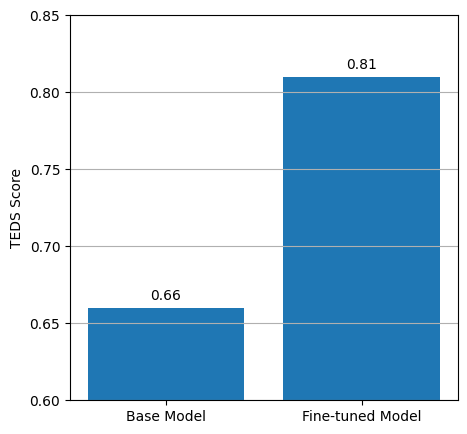

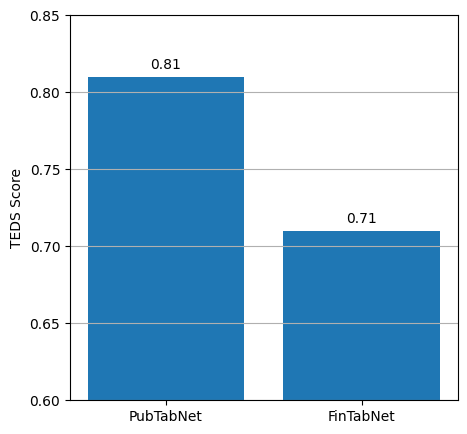

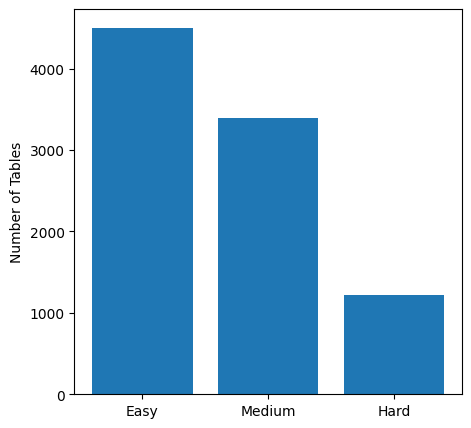

In [ ]:
import matplotlib.pyplot as plt

# Data
dataset_sizes = [2000, 5000, 10000]
teds_scores = [0.67, 0.79, 0.81]

# Plot
plt.figure(figsize=(6,5))

plt.plot(dataset_sizes, teds_scores, marker='o', linewidth=2)

# Labels
plt.xlabel("Training Dataset Size")
plt.ylabel("TEDS Score")

# IMPORTANT: set limits for better visualization
plt.ylim(0.6, 0.85)

# Grid
plt.grid(True)

# Show values on points
for x, y in zip(dataset_sizes, teds_scores):
    plt.text(x, y + 0.005, f"{y:.2f}", ha='center')

# Save
plt.savefig("/content/drive/MyDrive/teds_scaling.png", dpi=300)

plt.show()





import matplotlib.pyplot as plt

# Data
models = ["Base Model", "Fine-tuned Model"]
teds_scores = [0.66, 0.81]

# Plot
plt.figure(figsize=(5,5))

bars = plt.bar(models, teds_scores)

# Labels
plt.ylabel("TEDS Score")
plt.ylim(0.6, 0.85)

# Values on bars
for i, v in enumerate(teds_scores):
    plt.text(i, v + 0.005, f"{v:.2f}", ha='center')

# Grid
plt.grid(axis='y')

# Save
plt.savefig("/content/drive/MyDrive/base_vs_finetuned_simple.png", dpi=300)

plt.show()







import matplotlib.pyplot as plt

# Data
datasets = ["PubTabNet", "FinTabNet"]
teds_scores = [0.81, 0.71]

# Plot
plt.figure(figsize=(5,5))

bars = plt.bar(datasets, teds_scores)

# Labels
plt.ylabel("TEDS Score")
plt.ylim(0.6, 0.85)

# Values on bars
for i, v in enumerate(teds_scores):
    plt.text(i, v + 0.005, f"{v:.2f}", ha='center')

# Grid
plt.grid(axis='y')

# Save
plt.savefig("/content/drive/MyDrive/cross_dataset.png", dpi=300)

plt.show()





import json
import matplotlib.pyplot as plt

with open("/content/drive/MyDrive/DataSet/full_validation_logs_10k.json") as f:
    logs = json.load(f)

teds = [x["teds"] for x in logs]

easy = sum(1 for x in teds if x > 0.85)
medium = sum(1 for x in teds if 0.6 <= x <= 0.85)
hard = sum(1 for x in teds if x < 0.6)

labels = ["Easy", "Medium", "Hard"]
values = [easy, medium, hard]

plt.figure(figsize=(5,5))
plt.bar(labels, values)

plt.ylabel("Number of Tables")

plt.savefig("/content/drive/MyDrive/difficulty_analysis.png", dpi=300)
plt.show()

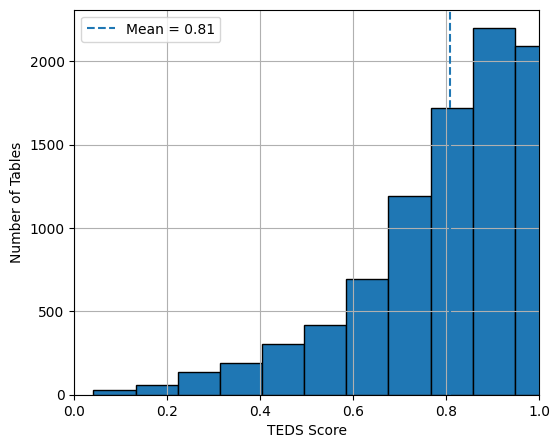

In [ ]:
import json
import matplotlib.pyplot as plt

# Load data
with open("/content/drive/MyDrive/DataSet/full_validation_logs_10k.json") as f:
    logs = json.load(f)

teds_scores = [x["teds"] for x in logs]

# Plot
plt.figure(figsize=(6,5))

plt.hist(teds_scores, bins=20, edgecolor='black')

# Mean line
mean_score = sum(teds_scores) / len(teds_scores)
plt.axvline(mean_score, linestyle='--', label=f"Mean = {mean_score:.2f}")

# Labels
plt.xlabel("TEDS Score")
plt.ylabel("Number of Tables")

plt.xlim(0, 1)

plt.legend()
plt.grid(True)

plt.savefig("/content/drive/MyDrive/teds_histogram_with_mean.png", dpi=300)

plt.show()